1.1 Purpose (introduction)
--
After my first challenge (resume screener) i came to the conclusion that i understand concept well and can locate any material when i need to code but the project itself lacked a few key elements such as a good dataset and a proper pipeline.
Therefore for my second challenge i am creating a model that can detect fish based on images. this can be used by people that do hobby fishing and what to know what family of fish they caught.

1.2 Pipeline 
--
User inputs image -> Model Looks at image -> detect where the fish is within the image -> check what family the fish belongs to -> outputs family

1.3 supporting documentation
--
https://www.sciencedirect.com/science/article/pii/S0950705125004654 
this article explore something similiar to what i am doing and i will use this as a general 'help me' guide instead of running to AI

1.4 Models
--
according to my research and the research document im using as guidance there are two type of detection classes: "one-stage detectors and two-stage detectors. The one-stage detectors, such as the YOLO series, which predict object categories and bounding box in a single step, are the popular paradigms for fish detection. While two-stage detectors such as Fast RCNN , Faster-RCNN  and Mask-RCNN , use a divide-and-conquer approach, focusing on generating region proposals in the first stage and then on refining these proposals in the second stage to improve accuracy. "

1.5 Dataset
--
I am using the Fisnet dataset https://github.com/faixan-khan/FishNet/
This dataset is based on an aquatic biological taxonomy, consisting of 8 taxonomic classes, 83 orders, 463 families, 3,826 genera, 17,357 species, and 94,532 images. The dataset also includes bounding box annotations for fish detection. Additionally, the dataset encompasses 22 traits, grouped into three categories: habitat, ecological rule, and nutritional value.

1.6 Resources used to help find and fix code
--
https://stackoverflow.com/

In [ ]:
import os
import random
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn

In [10]:
import os

count = 0
for root_dir, cur_dir, files in os.walk(r'C:\Machine learning\Fish-identifier\Image_Library'):
    count += len(files)
print('file count:', count)

file count: 95032


So in total there are 95032 images within this dataset. before proceeding i want to check the exact balance for each family. also to note the images contain allot of background noise for example

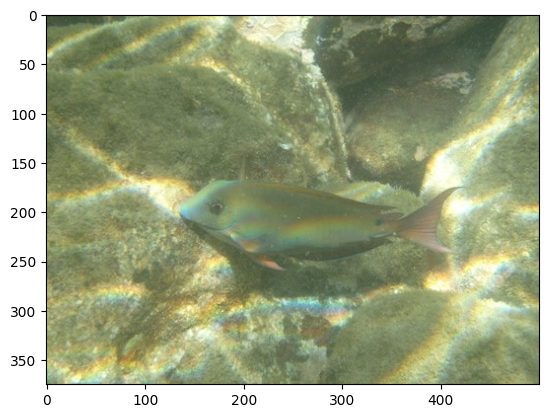

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('C:\\Machine learning\\Fish-identifier\\Image_Library\\Acanthuridae\\0a654eda-0cb8-41a4-8a46-6866ff9ae0f9.jpg')
imgplot = plt.imshow(img)
plt.show()


in this example image we can clearly see the fish but a one stage model might struggle with this due to a few factors. 1. it takes the image as one entire input and does not crop down to find the object 2. in some images like this one the surroundings for the fish are nearly the same color, for us as human we can detect the difference with ease but a one stage model cannot. hence why i advise and will proceed with using two stage models. i will start with faster r-cnn and then try a more complex model later.

C:\Users\jones\AppData\Local\Temp\ipykernel_30532\1612710401.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_counts.keys())[:70], y=list(sorted_counts.values())[:70], palette="viridis")


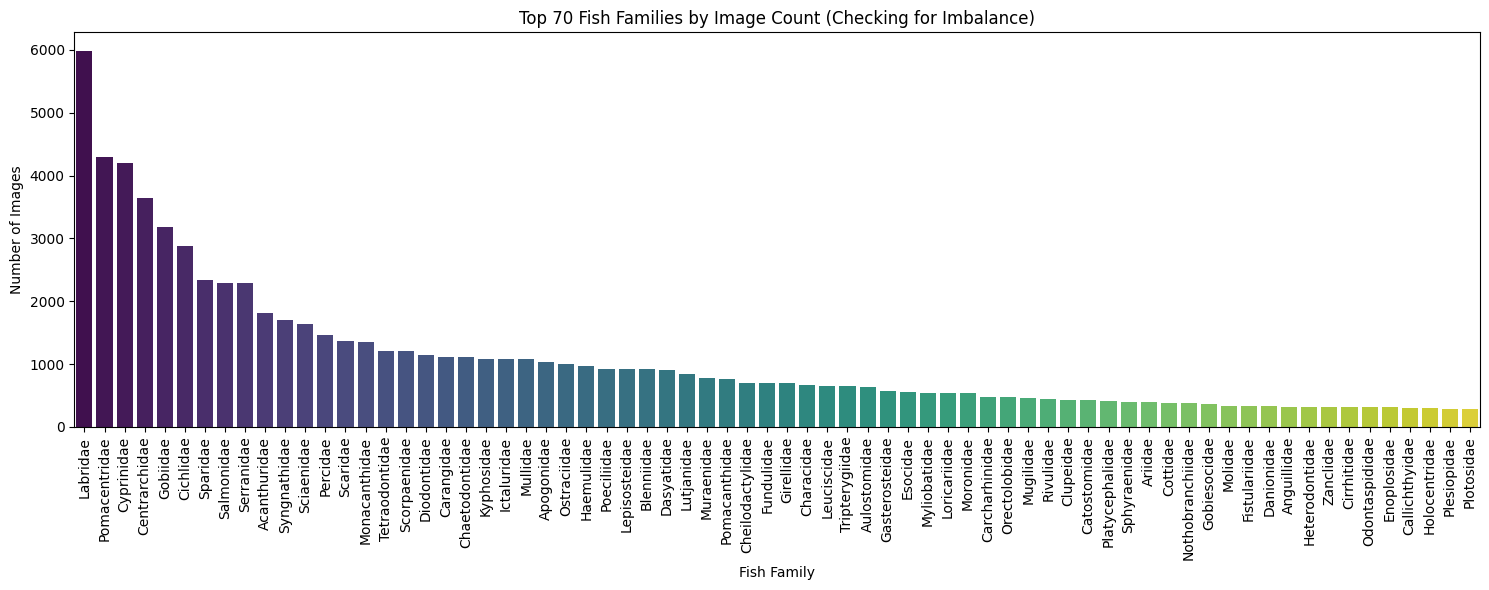

In [ ]:
import seaborn as sns

DATA_ROOT = r"C:\Machine learning\Fish-identifier\Image_Library"


family_counts = {}
for folder in os.listdir(DATA_ROOT):
    folder_path = os.path.join(DATA_ROOT, folder)
    if os.path.isdir(folder_path):

        images = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
        family_counts[folder] = len(images)


sorted_counts = dict(sorted(family_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6))
sns.barplot(x=list(sorted_counts.keys())[:70], y=list(sorted_counts.values())[:70], palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 70 Fish Families by Image Count (Checking for Imbalance)")
plt.xlabel("Fish Family")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

Whilst inspecting the folder its heavily unbalanced. some families(which are not shown in the graph) have less than 20 images which cannot be used for the training, i want to aim for atleast 40+ each family to squeeze out the best accuracy 

DATASET FILTERING SUMMARY (Threshold: 40 images)
Total unique families found: 570
Families KEPT: 199
Families DROPPED: 371
--------------------------------------------------

Top 5 Largest Families:
  - Labridae: 5978 images
  - Pomacentridae: 4288 images
  - Cyprinidae: 4192 images
  - Centrarchidae: 3635 images
  - Gobiidae: 3182 images

Preview of Dropped Families (Too few images):
  - Scombrolabracidae: 1 images
  - Steindachneriidae: 1 images
  - Stephanoberycidae: 1 images
  - Tetrabrachiidae: 1 images
  - Trichodontidae: 1 images


C:\Users\jones\AppData\Local\Temp\ipykernel_30532\3451450766.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=families_to_plot, y=counts_to_plot, palette=colors)


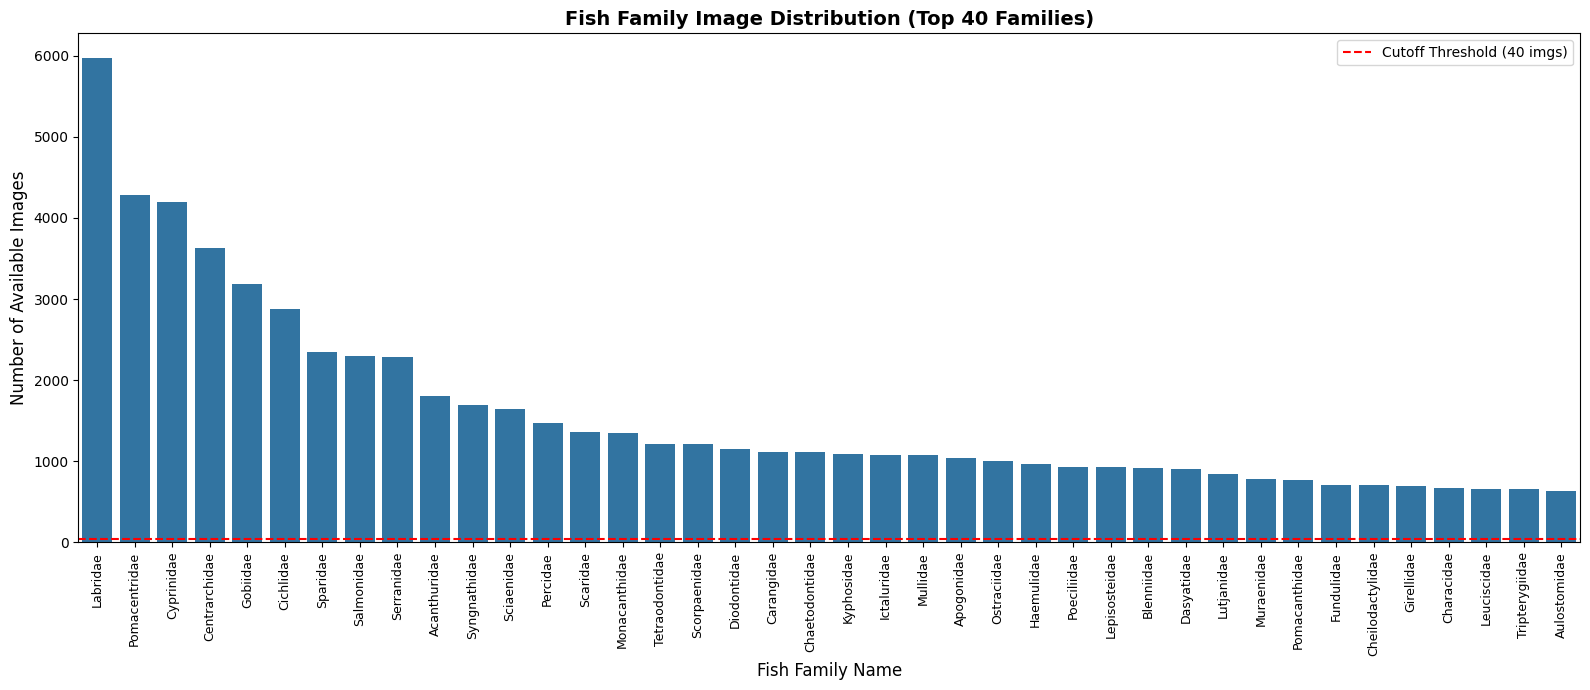

In [13]:
# i asked gemini to write code to filter out families with too few images, and to print 
# out a summary of the dataset balance. here is the code it generated:
MIN_IMAGES = 40

family_counts = {}

# 1. Scan and count files in each folder
for folder in os.listdir(DATA_ROOT):
    folder_path = os.path.join(DATA_ROOT, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        family_counts[folder] = len(images)

sorted_families = sorted(family_counts.items(), key=lambda item: item[1], reverse=True)

kept_families = [fam for fam, count in sorted_families if count >= MIN_IMAGES]
dropped_families = [fam for fam, count in sorted_families if count < MIN_IMAGES]

# 3. Print out the dataset summary
print("=" * 50)
print(f"DATASET FILTERING SUMMARY (Threshold: {MIN_IMAGES} images)")
print("=" * 50)
print(f"Total unique families found: {len(family_counts)}")
print(f"Families KEPT: {len(kept_families)}")
print(f"Families DROPPED: {len(dropped_families)}")
print("-" * 50)

print("\nTop 5 Largest Families:")
for fam, count in sorted_families[:5]:
    print(f"  - {fam}: {count} images")

print("\nPreview of Dropped Families (Too few images):")
for fam, count in sorted_families[-5:]:
    print(f"  - {fam}: {count} images")
print("=" * 50)

top_n = 40
plot_data = sorted_families[:top_n]
families_to_plot = [item[0] for item in plot_data]
counts_to_plot = [item[1] for item in plot_data]

plt.figure(figsize=(16, 7))
# Color code bars: distinct color if it's close to the threshold cutoff
colors = ['#1f77b4' if count >= MIN_IMAGES else '#d62728' for count in counts_to_plot]

sns.barplot(x=families_to_plot, y=counts_to_plot, palette=colors)
plt.axhline(y=MIN_IMAGES, color='r', linestyle='--', label=f'Cutoff Threshold ({MIN_IMAGES} imgs)')

plt.xticks(rotation=90, fontsize=9)
plt.title(f"Fish Family Image Distribution (Top {top_n} Families)", fontsize=14, fontweight='bold')
plt.xlabel("Fish Family Name", fontsize=12)
plt.ylabel("Number of Available Images", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Unfortunately i had to drop certain fish families before creating the datatset because they lacked enough images for training. after reading through the documentation and doing some research online it's genuinely recommended to have atleast 40 images for the model to train on so it can actually learn the differences. i will also cap the images to 300 since some families have over 5000+ images and i don't want the model to only be exposed to those family of fish. (note improve the cutoff so that its perfectly balanced)

In [ ]:
BBOX_DIR = r'C:\Machine learning\Fish-identifier\all_family'

MIN_IMAGES = 40
MAX_IMAGES = 300 
family_pairs = {} 

for folder in os.listdir(DATA_ROOT):
    img_folder_path = os.path.join(DATA_ROOT, folder)
    bbox_folder_path = os.path.join(BBOX_DIR, folder)
    
    if os.path.isdir(img_folder_path) and os.path.exists(bbox_folder_path):
        valid_pairs_in_family = []
        images = [f for f in os.listdir(img_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_name in images:
            base_name = os.path.splitext(img_name)[0]
            bbox_path = os.path.join(bbox_folder_path, f"{base_name}.txt")
            img_path = os.path.join(img_folder_path, img_name)
            
            if os.path.exists(bbox_path):
                valid_pairs_in_family.append((img_path, bbox_path))
        
        if len(valid_pairs_in_family) > 0:
            family_pairs[folder] = valid_pairs_in_family


final_img_paths = []
final_labels = []
bbox_lookup_dict = {}
valid_families = []

for family, pairs in family_pairs.items():
   
    if len(pairs) < MIN_IMAGES:
        continue
        
    valid_families.append(family)
    
    # Ceiling check: if it exceeds 300, randomly downsample the pairs
    if len(pairs) > MAX_IMAGES:
        pairs = random.sample(pairs, MAX_IMAGES)
        
    
    for img_path, bbox_path in pairs:
        img_name = os.path.basename(img_path)
        image_boxes = []
        
        # Parse coordinates
        with open(bbox_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                x, y, w, h = map(float, parts[1:5])
                xmin, ymin, xmax, ymax = x, y, x + w, y + h
                image_boxes.append([xmin, ymin, xmax, ymax])
                
        if len(image_boxes) > 0:
            orig_w, orig_h = Image.open(img_path).size
            scale_x, scale_y = 800 / orig_w, 800 / orig_h
            scaled = [[b[0]*scale_x, b[1]*scale_y,
                          b[2]*scale_x, b[3]*scale_y] for b in image_boxes]
            bbox_lookup_dict[img_name] = scaled
            final_img_paths.append(img_path)
            final_labels.append(family)

valid_families.sort()
# Map families to integer labels (0 = background, fish start at 1)
family_to_idx = {name: idx + 1 for idx, name in enumerate(valid_families)}
num_classes = len(valid_families) + 1

print("=" * 50)
print(f"BALANCED DATASET PROFILE:")
print(f"Total Fish Families Evaluated: {num_classes - 1}")
print(f"Total Images loaded (Balanced & Capped): {len(final_img_paths)}")
print("=" * 50)

BALANCED DATASET PROFILE:
Total Fish Families Evaluated: 196
Total Images loaded (Balanced & Capped): 34710


Now that the families were balanced i can move on to creating my dataset class, the dataloader and then moving on to training and evaluation. (note do some research on how the dataset class for images work)

In [ ]:
class FishDataset(Dataset):
    def __init__(self, img_paths, labels, bbox_lookup, family_to_idx, transforms=None):
        self.img_paths = img_paths
        self.labels = labels
        self.bbox_lookup = bbox_lookup
        self.family_to_idx = family_to_idx
        self.transforms = transforms

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert("RGB")
        
        img_name = os.path.basename(img_path)
        boxes = self.bbox_lookup[img_name] 
        family = self.labels[idx]
        label_idx = self.family_to_idx[family]
        boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
        # One label per box — all boxes in this image belong to the same family
        labels_tensor = torch.tensor([label_idx] * len(boxes), dtype=torch.int64)

        target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

In [ ]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    final_img_paths, final_labels, test_size=0.2, random_state=42, stratify=final_labels
)

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((800, 800)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((800, 800)),
    transforms.ToTensor(),
])

train_dataset = FishDataset(train_paths, train_labels, bbox_lookup_dict, family_to_idx, train_transforms)
val_dataset   = FishDataset(val_paths,   val_labels,   bbox_lookup_dict, family_to_idx, val_transforms)

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  collate_fn=collate_fn, num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=4)

Faster R-CNN images in a batch can have different numbers of boxes, so I can't use the default collation, therefore i made a custom one under collate_fn

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model = model.to(device)

After a discussion with bas i ended up using mobilenet as the backbone for my first interation since its a 2 stage detector that is a bit faster, and for the second iteration i will then use the resnet for a comparison so i can make a strong argument on my decisions

In [ ]:

PATIENCE = 3     
MIN_DELTA = 0.001 
NUM_EPOCHS = 50     

best_loss = float("inf")
epochs_no_improve = 0

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} — Loss: {avg_loss:.4f}")

    lr_scheduler.step()
    lr_scheduler.optimizer.zero_grad()

    # Early stopping check
    if avg_loss < best_loss - MIN_DELTA:
        best_loss = avg_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")  # my checkpoint saving so i don't lose the best model
        print(f" model saved (best loss: {best_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            break

model.load_state_dict(torch.load("best_model.pth"))
print("Best model restored.")

In [ ]:
from torchmetrics.detection import MeanAveragePrecision
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

CONFIDENCE_THRESHOLD = 0.5

map_metric = MeanAveragePrecision(iou_type="bbox")

all_true_labels = []
all_pred_labels = []
all_confidences = []

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = model(images)

        map_metric.update(preds, targets)

        for pred, target in zip(preds, targets):
            true_label = target["labels"][0].item()

            confident_mask = pred["scores"] >= CONFIDENCE_THRESHOLD
            for true_label in target["labels"]:
             true_label = true_label.item()
            if confident_mask.sum() == 0:
                all_true_labels.append(true_label)
                all_pred_labels.append(-1)
                all_confidences.append(0.0)
            else:

                best_idx   = pred["scores"][confident_mask].argmax()
                best_label = pred["labels"][confident_mask][best_idx].item()
                best_score = pred["scores"][confident_mask][best_idx].item()
                all_true_labels.append(true_label)
                all_pred_labels.append(best_label)
                all_confidences.append(best_score)

# --- mAP ---
map_results = map_metric.compute()
print("=" * 50)
print("DETECTION PERFORMANCE (mAP)")
print("=" * 50)
print(f"  mAP @ IoU 0.50:0.95 : {map_results['map'].item():.4f}")
print(f"  mAP @ IoU 0.50      : {map_results['map_50'].item():.4f}")
print(f"  mAP @ IoU 0.75      : {map_results['map_75'].item():.4f}")

# --- Confidence summary ---
all_confidences = np.array(all_confidences)
all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)

missed   = (all_pred_labels == -1).sum()
detected = (all_pred_labels != -1).sum()
correct  = ((all_pred_labels == all_true_labels) & (all_pred_labels != -1)).sum()

print("\n" + "=" * 50)
print("CONFIDENCE SUMMARY")
print("=" * 50)
print(f"  Total validation images : {len(all_true_labels)}")
print(f"  Detected (>={CONFIDENCE_THRESHOLD})       : {detected}  ({100*detected/len(all_true_labels):.1f}%)")
print(f"  Missed / low confidence : {missed}  ({100*missed/len(all_true_labels):.1f}%)")
print(f"  Correct classifications : {correct}  ({100*correct/detected:.1f}% of detected)")

# Confidence plots
correct_mask = (all_pred_labels == all_true_labels) & (all_pred_labels != -1)
wrong_mask   = (all_pred_labels != all_true_labels) & (all_pred_labels != -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_confidences[all_confidences > 0], bins=20, color="#1f77b4", edgecolor="white")
axes[0].axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({CONFIDENCE_THRESHOLD})")
axes[0].set_title("Confidence Score Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Number of Predictions")
axes[0].legend()

axes[1].hist(all_confidences[correct_mask], bins=20, alpha=0.6, color="green", label="Correct")
axes[1].hist(all_confidences[wrong_mask],   bins=20, alpha=0.6, color="red",   label="Incorrect")
axes[1].set_title("Correct vs Incorrect by Confidence", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Confidence Score")
axes[1].set_ylabel("Number of Predictions")
axes[1].legend()

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150)
plt.show()

# --- Confusion matrix ---
detected_mask  = all_pred_labels != -1
cm_true = all_true_labels[detected_mask]
cm_pred = all_pred_labels[detected_mask]

idx_to_family  = {v: k for k, v in family_to_idx.items()}
present_labels = sorted(set(cm_true) | set(cm_pred))
display_names  = [idx_to_family.get(l, f"unknown_{l}") for l in present_labels]

cm            = confusion_matrix(cm_true, cm_pred, labels=present_labels)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

n        = len(present_labels)
fig_size = max(12, n * 0.35)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalised, display_labels=display_names)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=90, values_format=".2f")
ax.set_title("Confusion Matrix (Normalised)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nPlots saved: confidence_analysis.png, confusion_matrix.png")

In [ ]:
import matplotlib.patches as patches
def predict_image(img_path, model, family_to_idx, device, confidence_threshold=0.3, top_k=5):
    idx_to_family = {v: k for k, v in family_to_idx.items()}

    # Load and transform
    img = Image.open(img_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((800, 800)),
        transforms.ToTensor(),
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)  # add batch dimension

    # Run inference
    model.eval()
    with torch.no_grad():
        preds = model(img_tensor)[0]  # [0] because batch size is 1

    # Filter by confidence threshold
    confident_mask = preds["scores"] >= confidence_threshold
    boxes   = preds["boxes"][confident_mask].cpu()
    labels  = preds["labels"][confident_mask].cpu()
    scores  = preds["scores"][confident_mask].cpu()

    # --- Print top-k family predictions ---
    print("=" * 50)
    print(f"IMAGE: {os.path.basename(img_path)}")
    print(f"Detections above {confidence_threshold} threshold: {len(scores)}")
    print("=" * 50)

    if len(scores) == 0:
        print("No confident detections found. Try lowering the confidence_threshold.")
        return

    # Aggregate scores per family (an image may have multiple boxes of the same family)
    family_scores = {}
    for label, score in zip(labels, scores):
        family_name = idx_to_family.get(label.item(), f"unknown_{label.item()}")
        # Keep the highest score seen for this family
        if family_name not in family_scores or score.item() > family_scores[family_name]:
            family_scores[family_name] = score.item()

    # Sort and print top-k
    ranked = sorted(family_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

    print(f"\nTop {top_k} predicted families:")
    for rank, (family, score) in enumerate(ranked, 1):
        bar = "█" * int(score * 30)  # visual confidence bar
        print(f"  {rank}. {family:<25} {score:.2%}  {bar}")

    # --- Visualise image with bounding boxes ---
    # Scale boxes back to original image size (we resized to 800x800 for inference)
    orig_w, orig_h = img.size
    scale_x = orig_w / 800
    scale_y = orig_h / 800

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # Colour each unique family differently
    unique_families = list({idx_to_family.get(l.item(), "unknown") for l in labels})
    colour_map = plt.colormaps["tab20"].resampled(len(unique_families))
    family_colours = {fam: colour_map(i) for i, fam in enumerate(unique_families)}

    for box, label, score in zip(boxes, labels, scores):
        family_name = idx_to_family.get(label.item(), f"unknown_{label.item()}")
        colour = family_colours[family_name]

        xmin, ymin, xmax, ymax = box.tolist()
        # Scale back to original dimensions
        xmin *= scale_x; xmax *= scale_x
        ymin *= scale_y; ymax *= scale_y

        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=colour, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            xmin, ymin - 5,
            f"{family_name} {score:.0%}",
            color="white", fontsize=8, fontweight="bold",
            bbox=dict(facecolor=colour, alpha=0.7, pad=2, edgecolor="none")
        )

    ax.axis("off")
    ax.set_title(f"Top prediction: {ranked[0][0]}  ({ranked[0][1]:.2%} confidence)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("prediction_result.png", dpi=150)
    plt.show()


img_path = r"C:\Machine learning\Fish-identifier\Image_Library\Acanthuridae\0a654eda-0cb8-41a4-8a46-6866ff9ae0f9.jpg"

predict_image(
    img_path    = img_path,
    model       = model,
    family_to_idx = family_to_idx,
    device      = device,
    confidence_threshold = 0.3,   
    top_k       = 5               
)

I asked gemini to imporve my confidence score script since i was running into some issues